In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
import glob
import tqdm
plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})

In [6]:
label_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/result/dorado-070-aligned/intermediates/dorado_output.pileup.T.pkl.sorted.pkl")
print(label_df)

             index          nmid    pos         label_id
0                0     NM_019091      1      NM_019091:1
1                1     NR_047507      2      NR_047507:2
2                2     NM_017908      2      NM_017908:2
3                3  NM_001080394      2   NM_001080394:2
4                4     NM_002805      2      NM_002805:2
...            ...           ...    ...              ...
32647792  32647792     NR_002728  82889  NR_002728:82889
32647793  32647793     NR_002728  82890  NR_002728:82890
32647794  32647794     NR_002728  82894  NR_002728:82894
32647795  32647795     NR_002728  82898  NR_002728:82898
32647796  32647796     NR_002728  82901  NR_002728:82901

[32647797 rows x 4 columns]


In [72]:
m5c_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-m5C-20240913-183902-47-469000-token_normalise_m5C_dwell_bq_npz_v2-ON0090_m5Cfinal/pileup_strid.genomic.pkl"
m5c_df = pd.read_pickle(m5c_df).reset_index(drop=True)
print(m5c_df)

                genome_id gene_symbol  coding  isoforms      pm6a       dom  \
0         chr10:+:1000684      GTPBP4    True         1  0.220301  0.137897   
1         chr10:+:1000686      GTPBP4    True         1  0.035624  0.017956   
2         chr10:+:1000688      GTPBP4    True         1  0.219997  0.224460   
3         chr10:+:1000689      GTPBP4    True         1  0.033026  0.031665   
4         chr10:+:1000696      GTPBP4    True         1 -0.000000  0.008064   
...                   ...         ...     ...       ...       ...       ...   
12553594   chrX:-:9760807      GPR143    True         1  0.000000  0.000000   
12553595   chrX:-:9760809      GPR143    True         1  0.000000  0.000000   
12553596   chrX:-:9760810      GPR143    True         1 -0.000000  0.093095   
12553597   chrX:-:9760814      GPR143    True         1 -0.000000  0.161494   
12553598   chrX:-:9760815      GPR143    True         1  0.406855  0.612038   

          count_all  logsum_1_p_pos  kl_div_pos  kl

In [9]:
dai_df = pd.read_csv("/extdata3/baeklab/Hyeonseo/m6A/res/m5Csites/Dai_UBS_293T_WT.txt", sep="\t")
huang_df = pd.read_csv("/extdata3/baeklab/Hyeonseo/m6A/res/m5Csites/Huang_BS_293T_WT.txt", sep="\t")

print(dai_df)
print(huang_df)

     chrom   position strand       gene_type                   gene_name  \
0        .          .      +            rRNA               rRNA-RNA28SN1   
1        .          .      +            rRNA               rRNA-RNA28SN1   
2        .          .      +            tRNA            tRNA-Asp-GTC-1-1   
3        .          .      +            tRNA            tRNA-Asp-GTC-2-1   
4        .          .      +            tRNA            tRNA-Asp-GTC-2-1   
...    ...        ...    ...             ...                         ...   
2391     X  154477859      -  protein_coding      ENSG00000196976(LAGE3)   
2392     X  154485837      -  protein_coding      ENSG00000102178(UBL4A)   
2393     X  154488508      -  protein_coding    ENSG00000126903(SLC10A3)   
2394     X  155126223      +  Other features      ENSG00000185515(BRCC3)   
2395     Y   10200182      +      pseudogene  ENSG00000251705(RNA5-8SP6)   

     gene_pos  unconverted  converted     ratio  
0        3779         4305        186

In [10]:
atlas_df = pd.read_csv("/extdata3/baeklab/Hyeonseo/m6A/res/m5Csites/m5Catlas_hg19.csv")

In [11]:
atlas_df = atlas_df[['seqnames', 'start', 'strand']]
print(atlas_df)

       seqnames      start strand
0          chr1      16735      -
1          chr1     135156      -
2          chr1     136341      -
3          chr1     662448      -
4          chr1     662839      -
...         ...        ...    ...
134644     chr2  242627224      +
134645     chr2  242627227      +
134646     chr7  128293553      +
134647     chr2  242627225      +
134648     chr8  145692679      +

[134649 rows x 3 columns]


In [12]:
import liftover

In [13]:
lo = liftover.get_lifter('hg19', 'hg38')

In [14]:
atlas_df["hg38"] = atlas_df.apply(lambda x: lo[x["seqnames"]][x["start"]], axis=1)

In [17]:
atlas_df = atlas_df[atlas_df["hg38"].apply(len) == 1].copy()
print(atlas_df)

       seqnames      start strand                    hg38
0          chr1      16735      -      [(chr1, 16735, +)]
1          chr1     135156      -     [(chr1, 135156, +)]
2          chr1     136341      -     [(chr1, 136341, +)]
3          chr1     662448      -     [(chr1, 727068, +)]
4          chr1     662839      -     [(chr1, 727459, +)]
...         ...        ...    ...                     ...
134644     chr2  242627224      +  [(chr2, 241687809, +)]
134645     chr2  242627227      +  [(chr2, 241687812, +)]
134646     chr7  128293553      +  [(chr7, 128653499, +)]
134647     chr2  242627225      +  [(chr2, 241687810, +)]
134648     chr8  145692679      +  [(chr8, 144467296, +)]

[134644 rows x 4 columns]


In [18]:
atlas_df["chr"] = atlas_df["hg38"].apply(lambda x: x[0][0])
atlas_df["pos"] = atlas_df["hg38"].apply(lambda x: x[0][1])

atlas_df = atlas_df[["chr", "pos", "strand"]]
print(atlas_df)

         chr        pos strand
0       chr1      16735      -
1       chr1     135156      -
2       chr1     136341      -
3       chr1     727068      -
4       chr1     727459      -
...      ...        ...    ...
134644  chr2  241687809      +
134645  chr2  241687812      +
134646  chr7  128653499      +
134647  chr2  241687810      +
134648  chr8  144467296      +

[134644 rows x 3 columns]


In [45]:
ubs_df = dai_df.copy()
ubs_df["depth"] = ubs_df["unconverted"] + ubs_df["converted"]
print(ubs_df)

     chrom   position strand       gene_type                   gene_name  \
0        .          .      +            rRNA               rRNA-RNA28SN1   
1        .          .      +            rRNA               rRNA-RNA28SN1   
2        .          .      +            tRNA            tRNA-Asp-GTC-1-1   
3        .          .      +            tRNA            tRNA-Asp-GTC-2-1   
4        .          .      +            tRNA            tRNA-Asp-GTC-2-1   
...    ...        ...    ...             ...                         ...   
2391     X  154477859      -  protein_coding      ENSG00000196976(LAGE3)   
2392     X  154485837      -  protein_coding      ENSG00000102178(UBL4A)   
2393     X  154488508      -  protein_coding    ENSG00000126903(SLC10A3)   
2394     X  155126223      +  Other features      ENSG00000185515(BRCC3)   
2395     Y   10200182      +      pseudogene  ENSG00000251705(RNA5-8SP6)   

     gene_pos  unconverted  converted     ratio  depth  
0        3779         4305    

In [46]:
ubs_df = ubs_df[["chrom", "position", "strand"]].copy()
ubs_df.rename(columns = {"chrom": "chr", "position": "pos"}, inplace = True)
ubs_df["chr"] = ubs_df["chr"].apply(lambda x: "chr" + x)
ubs_df = ubs_df[ubs_df["pos"]!="."].copy()
ubs_df["pos"] = ubs_df["pos"].astype(np.int64)
print(ubs_df)


       chr        pos strand
205   chr1     918816      -
206   chr1     941220      +
207   chr1     944475      +
208   chr1     999131      -
209   chr1     999142      -
...    ...        ...    ...
2391  chrX  154477859      -
2392  chrX  154485837      -
2393  chrX  154488508      -
2394  chrX  155126223      +
2395  chrY   10200182      +

[2191 rows x 3 columns]


In [22]:
print(atlas_df)

         chr        pos strand
0       chr1      16735      -
1       chr1     135156      -
2       chr1     136341      -
3       chr1     727068      -
4       chr1     727459      -
...      ...        ...    ...
134644  chr2  241687809      +
134645  chr2  241687812      +
134646  chr7  128653499      +
134647  chr2  241687810      +
134648  chr8  144467296      +

[134644 rows x 3 columns]


In [47]:
atlas_df["atlas"] = 1
ubs_df["ubs"] = 1
ubs_atlas_df = ubs_df.merge(atlas_df, on=["chr", "pos", "strand"], how="outer")
ubs_atlas_df.fillna(0, inplace=True)
ubs_atlas_df["genome_id"] = ubs_atlas_df["chr"] +":" + ubs_atlas_df["strand"]+ ":" + (ubs_atlas_df["pos"]-1).astype(str)
print(ubs_atlas_df)

         chr        pos strand  ubs  atlas         genome_id
0       chr1     918816      -  1.0    0.0     chr1:-:918815
1       chr1     941220      +  1.0    1.0     chr1:+:941219
2       chr1     944475      +  1.0    0.0     chr1:+:944474
3       chr1     999131      -  1.0    0.0     chr1:-:999130
4       chr1     999142      -  1.0    0.0     chr1:-:999141
...      ...        ...    ...  ...    ...               ...
136307  chr7  128653520      +  0.0    1.0  chr7:+:128653519
136308  chr2  241687809      +  0.0    1.0  chr2:+:241687808
136309  chr2  241687812      +  0.0    1.0  chr2:+:241687811
136310  chr7  128653499      +  0.0    1.0  chr7:+:128653498
136311  chr2  241687810      +  0.0    1.0  chr2:+:241687809

[136312 rows x 6 columns]


In [73]:
eval_df = m5c_df[m5c_df["count_all"]>=20].merge(ubs_atlas_df[["genome_id", "atlas", "ubs"]], on="genome_id", how="left").fillna(0)
print(eval_df[eval_df["ubs"]==1])

                 genome_id   gene_symbol  coding  isoforms      pm6a  \
1198     chr10:+:100364290           SCD    True         1  0.046584   
8099     chr10:+:101003881         LZTS2    True         6  0.582142   
11502    chr10:+:101238571      LBX1-AS1   False         1  2.221986   
18131    chr10:+:102375536          GBF1    True        13  0.228055   
20475    chr10:+:102455624  C10orf95-AS1   False         2  0.229513   
...                    ...           ...     ...       ...       ...   
9563780    chrX:-:73843307          XIST   False         1  0.061709   
9565500    chrX:-:73850013          XIST   False         1  0.000000   
9570557    chrX:-:77870879         MAGT1    True         2  0.014977   
9573242    chrX:-:84061894       RPS6KA6    True         2  0.271329   
9573634    chrX:-:84065013       RPS6KA6    True         2  1.273690   

              dom  count_all  logsum_1_p_pos  kl_div_pos   kl_div_neg  atlas  \
1198     0.017896       2902      -68.754356   47.11143

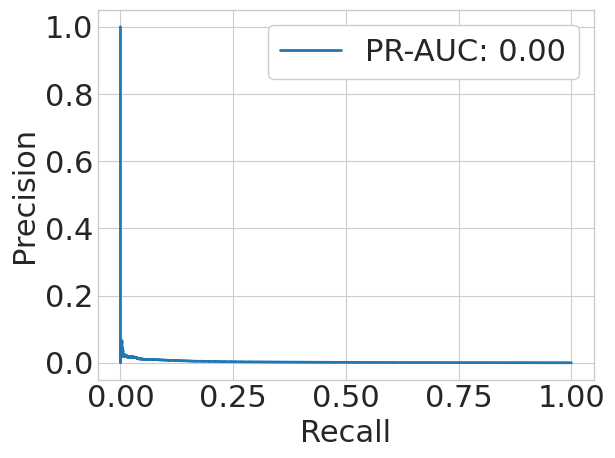

In [75]:
## P-R curve
from sklearn.metrics import precision_recall_curve, auc

precision, recall, _ = precision_recall_curve(eval_df["ubs"], eval_df["pm6a"])
pr_auc = auc(recall, precision)
plt.plot(recall, precision, label=f"PR-AUC: {pr_auc:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

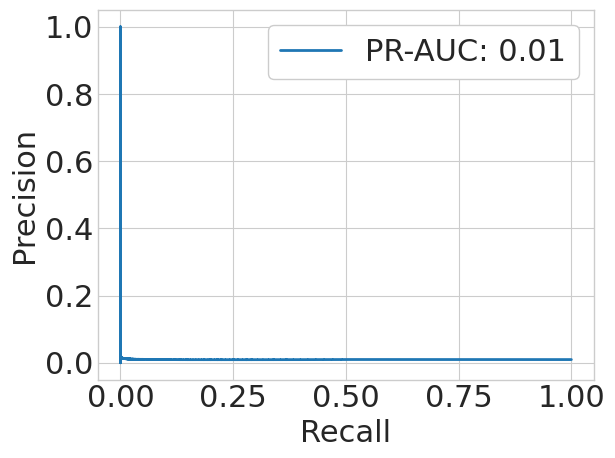

In [76]:
## P-R curve
from sklearn.metrics import precision_recall_curve, auc 
precision, recall, _ = precision_recall_curve(eval_df["atlas"], eval_df["pm6a"])
pr_auc = auc(recall, precision)
plt.plot(recall, precision, label=f"PR-AUC: {pr_auc:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

In [164]:
ubs_df = dai_df.copy()
ubs_df["depth"] = ubs_df["unconverted"] + ubs_df["converted"]
ubs_df["valid"] = (ubs_df["depth"] >= 20) & (ubs_df["ratio"] >= 0.1)
ubs_df = ubs_df[["chrom", "position", "strand","valid"]].copy()
ubs_df.rename(columns = {"chrom": "chr", "position": "pos"}, inplace = True)
ubs_df["chr"] = ubs_df["chr"].apply(lambda x: "chr" + x)
ubs_df = ubs_df[ubs_df["pos"]!="."].copy()
ubs_df["pos"] = ubs_df["pos"].astype(np.int64)
print(ubs_df)


       chr        pos strand  valid
205   chr1     918816      -   True
206   chr1     941220      +   True
207   chr1     944475      +   True
208   chr1     999131      -  False
209   chr1     999142      -  False
...    ...        ...    ...    ...
2391  chrX  154477859      -  False
2392  chrX  154485837      -  False
2393  chrX  154488508      -   True
2394  chrX  155126223      +   True
2395  chrY   10200182      +  False

[2191 rows x 4 columns]


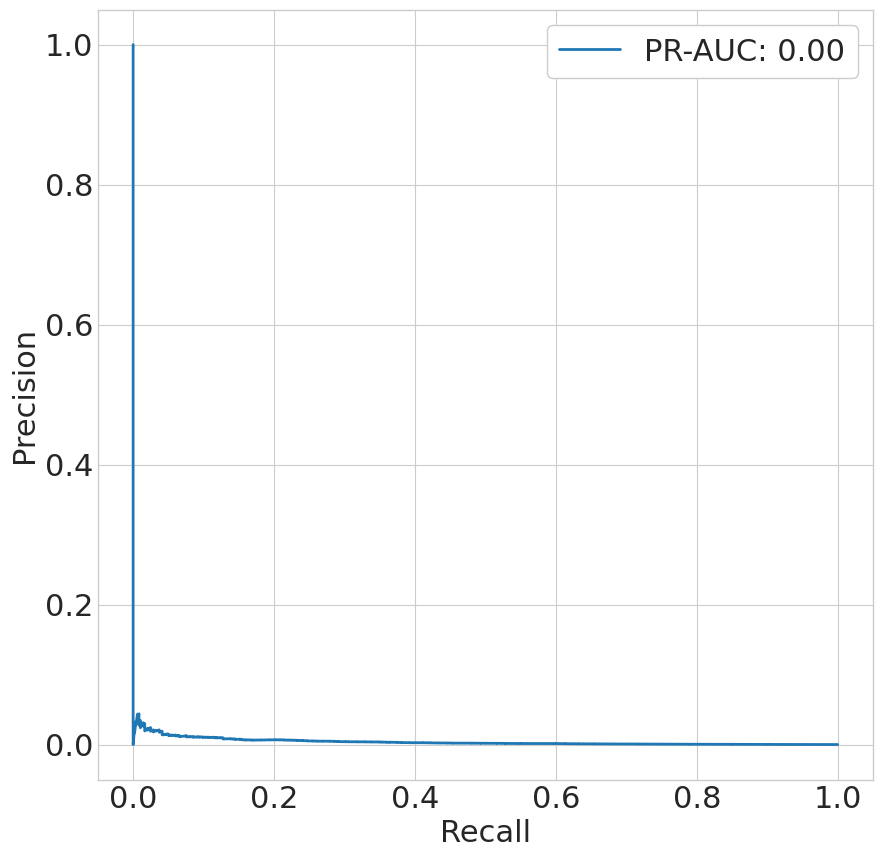

In [195]:
precision, recall, _ = precision_recall_curve(m5c_df[m5c_df["valid"]>=0]["valid"], m5c_df[m5c_df["valid"]>=0]["log_pm6a"])
pr_auc = auc(recall, precision)
fig, ax = plt.subplots(1,1,figsize=(10,10))
plt.plot(recall, precision, label=f"PR-AUC: {pr_auc:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

In [181]:
dorado_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/dorado-080/ON0090_dorado_basecall.bed.m5C.genomic.pkl")
dorado_df = dorado_df.reset_index(drop=True).merge(ubs_atlas_df[["genome_id", "valid"]], on="genome_id", how="left").fillna(0)
dorado_df = dorado_df[dorado_df["coumt_dom"]>=20].copy()
print(dorado_df)


                genome_id gene_symbol       dom  count_dom  coding  valid
0         chr10:+:1000678      GTPBP4  0.000000          1    True    0.0
1         chr10:+:1000684      GTPBP4  0.004274        468    True    0.0
2         chr10:+:1000686      GTPBP4  0.006479        463    True    0.0
3         chr10:+:1000687      GTPBP4  0.000000          1    True    0.0
4         chr10:+:1000688      GTPBP4  0.010893        459    True    0.0
...                   ...         ...       ...        ...     ...    ...
22267274   chrX:-:9760807      GPR143  0.000000          4    True    0.0
22267275   chrX:-:9760809      GPR143  0.000000          5    True    0.0
22267276   chrX:-:9760810      GPR143  0.000000          4    True    0.0
22267277   chrX:-:9760814      GPR143  0.000000          5    True    0.0
22267278   chrX:-:9760815      GPR143  0.000000          3    True    0.0

[22267279 rows x 6 columns]


In [183]:
dorado_df = dorado_df[dorado_df["count_dom"]>=20].copy()
print(dorado_df)

                genome_id gene_symbol       dom  count_dom  coding  valid
1         chr10:+:1000684      GTPBP4  0.004274        468    True    0.0
2         chr10:+:1000686      GTPBP4  0.006479        463    True    0.0
4         chr10:+:1000688      GTPBP4  0.010893        459    True    0.0
5         chr10:+:1000689      GTPBP4  0.000000        496    True    0.0
6         chr10:+:1000696      GTPBP4  0.000000        439    True    0.0
...                   ...         ...       ...        ...     ...    ...
22266406   chrX:-:8732122       ANOS1  0.065789         76    True    0.0
22266407   chrX:-:8732125       ANOS1  0.000000         85    True    0.0
22266408   chrX:-:8732128       ANOS1  0.000000         68    True    0.0
22266409   chrX:-:8732131       ANOS1  0.015152         66    True    0.0
22266410   chrX:-:8732133       ANOS1  0.068182         44    True    0.0

[9641066 rows x 6 columns]


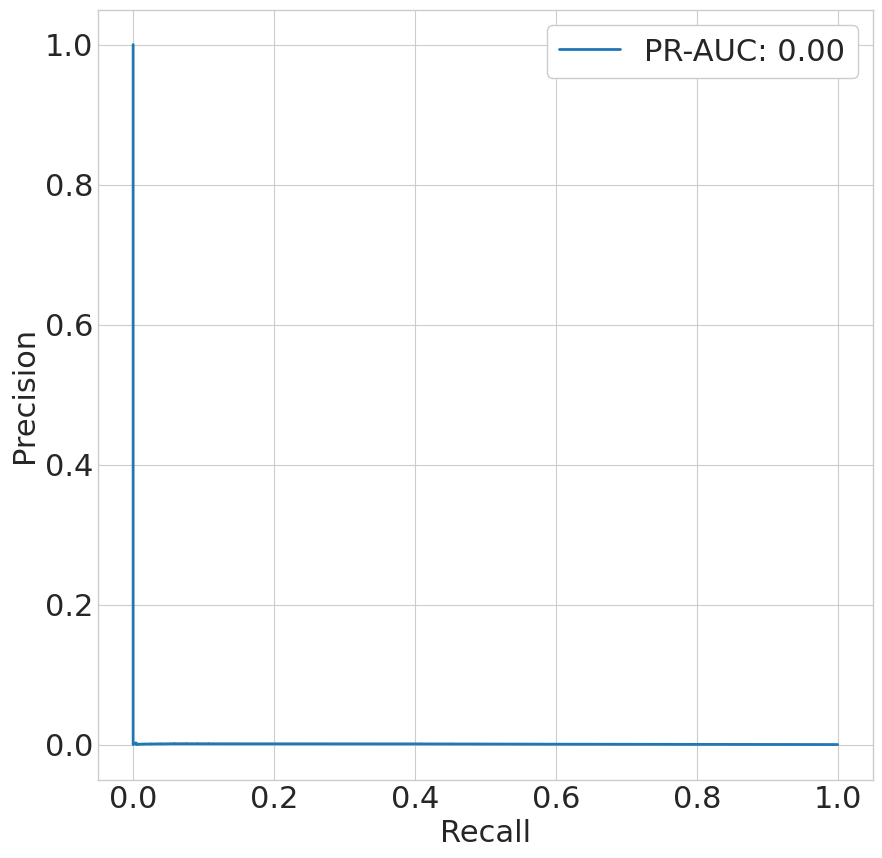

In [193]:
precision, recall, _ = precision_recall_curve(dorado_df[dorado_df["valid"]>=0]["valid"], dorado_df[dorado_df["valid"]>=0]["dom"])
pr_auc = auc(recall, precision)
fig, ax = plt.subplots(1,1,figsize=(10,10))
plt.plot(recall, precision, label=f"PR-AUC: {pr_auc:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

In [185]:
print(dorado_df[dorado_df["valid"]==1])

                  genome_id   gene_symbol       dom  count_dom  coding  valid
17927     chr10:+:101003881         LZTS2  0.126984        189    True    1.0
23370     chr10:+:101238571      LBX1-AS1  0.402299         87   False    1.0
37769     chr10:+:102455624  C10orf95-AS1  0.046296        324   False    1.0
132892    chr10:+:123155057          BUB3  0.067221       1324    True    1.0
144078    chr10:+:127433340         DOCK1  0.018987        158    True    1.0
...                     ...           ...       ...        ...     ...    ...
22157564    chrX:-:48957281         OTUD5  0.029605        304    True    1.0
22166129    chrX:-:49194237           SYP  0.125000         24    True    1.0
22213570    chrX:-:66597463         EDA2R  0.100000         30    True    1.0
22220770    chrX:-:71240386         ZMYM3  0.097674        215    True    1.0
22259959    chrX:-:84061894       RPS6KA6  0.000000         53    True    1.0

[517 rows x 6 columns]


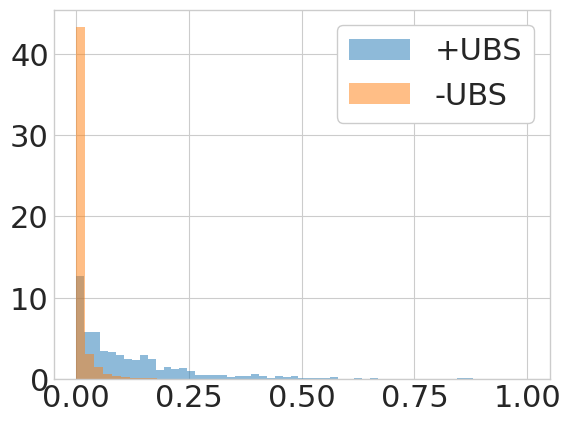

In [187]:
## Plot histogram
plt.hist(dorado_df[dorado_df["valid"]==1]["dom"], bins=50, alpha=0.5, label="+UBS",density=True)
plt.hist(dorado_df[dorado_df["valid"]==0]["dom"], bins=50, alpha=0.5, label="-UBS",density=True)
plt.legend()
plt.show()

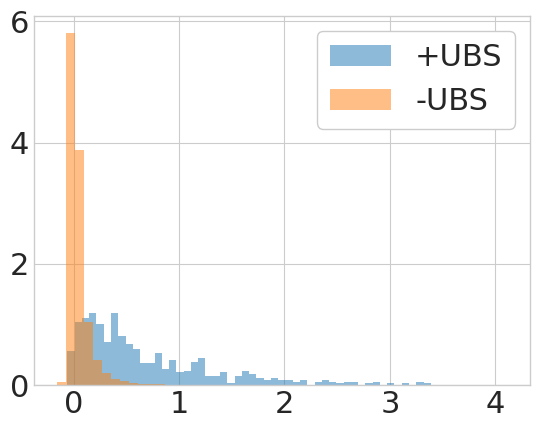

In [190]:
## Plot histogram
plt.hist(m5c_df[m5c_df["valid"]==1]["log_pm6a"], bins=50, alpha=0.5, label="+UBS",density=True)
plt.hist(m5c_df[m5c_df["valid"]==0]["log_pm6a"], bins=50, alpha=0.5, label="-UBS",density=True)
plt.legend()
plt.show()

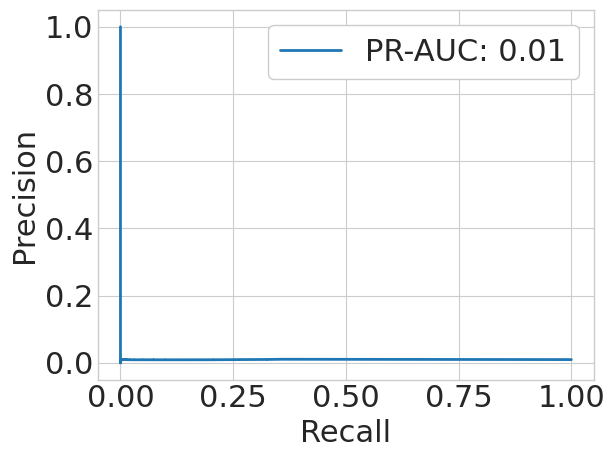

In [191]:
precision, recall, _ = precision_recall_curve(dorado_df["valid"].abs(), dorado_df["dom"])
pr_auc = auc(recall, precision)
plt.plot(recall, precision, label=f"PR-AUC: {pr_auc:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

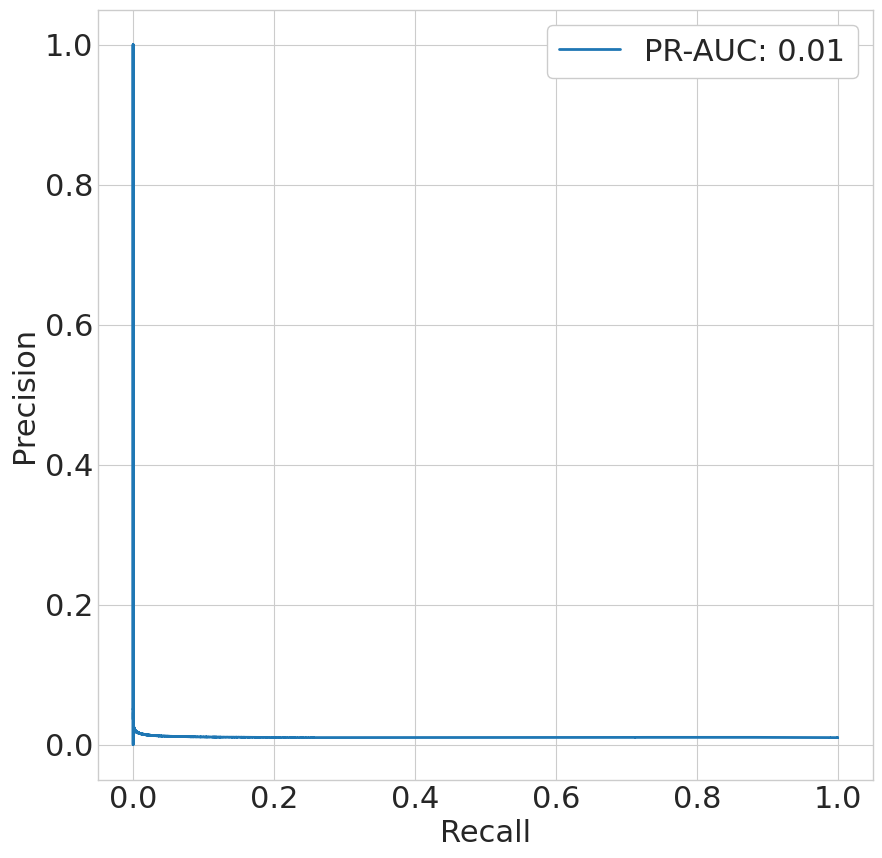

In [194]:
precision, recall, _ = precision_recall_curve(m5c_df["valid"].abs(), m5c_df["log_pm6a"])
pr_auc = auc(recall, precision)
fig, ax = plt.subplots(1,1,figsize=(10,10))
plt.plot(recall, precision, label=f"PR-AUC: {pr_auc:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

In [77]:
pseu_df = pd.concat([pd.read_pickle(x) for x in glob.glob("/extdata4/baeklab/Hyeonseo/m6A/pseU/validation/AIRNA-DW-v4-pseU-20241127-192353/*.pkl")])

In [78]:
m5c_df = pd.concat([pd.read_pickle(x) for x in glob.glob("/extdata4/baeklab/Hyeonseo/m6A/m5C/validation/AIRNA-DW-v4-pseU-20241127-212931/*.pkl")])

In [116]:
gm_df = pd.concat([pd.read_pickle(x) for x in glob.glob("/extdata4/baeklab/Hyeonseo/m6A/Gm/validation/AIRNA-DW-v4-pseU-20241129-101913/*.pkl")])

In [79]:
print(pseu_df)
print(m5c_df)

           output  target
0        1.000000       1
1        0.000713       0
2        0.000040       0
3        0.999997       1
4        0.999998       1
...           ...     ...
5785595  0.998112       1
5785596  0.999994       1
5785597  0.999999       1
5785598  0.156961       1
5785599  1.000000       1

[23142400 rows x 2 columns]
           output  target
0        0.999685       1
1        0.061747       0
2        0.014145       0
3        0.003479       1
4        0.382792       1
...           ...     ...
5785595  0.011291       0
5785596  0.055474       1
5785597  0.512535       0
5785598  0.015814       0
5785599  0.855234       1

[23142400 rows x 2 columns]


In [86]:
plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})

In [118]:
## Plot ROC, PR curve
from sklearn.metrics import precision_recall_curve, roc_curve, auc

def plot_roc_pr(df):
    fig, ax = plt.subplots(1,2,figsize=(20,10))
    precision, recall, _ = precision_recall_curve(df["target"], df["output"])
    pr_auc = auc(recall, precision)
    ax[0].plot(recall, precision, label=f"PR-AUC: {pr_auc:.3f}")
    fpr, tpr, _ = roc_curve(df["target"], df["output"])
    roc_auc = auc(fpr, tpr)
    
    f1 = 2 * (precision * recall) / (precision + recall)
    max_f1 = np.max(f1)
    
    ax[1].plot(fpr, tpr, label=f"ROC-AUC: {roc_auc:.3f}, Max F1: {max_f1:.3f}")
    ax[0].set_xlabel("Recall")
    ax[0].set_ylabel("Precision")
    ax[0].legend()
    ax[0].grid()
    ax[1].set_xlabel("FPR")
    ax[1].set_ylabel("TPR")
    ax[1].legend()
    ax[1].grid()
    plt.show()


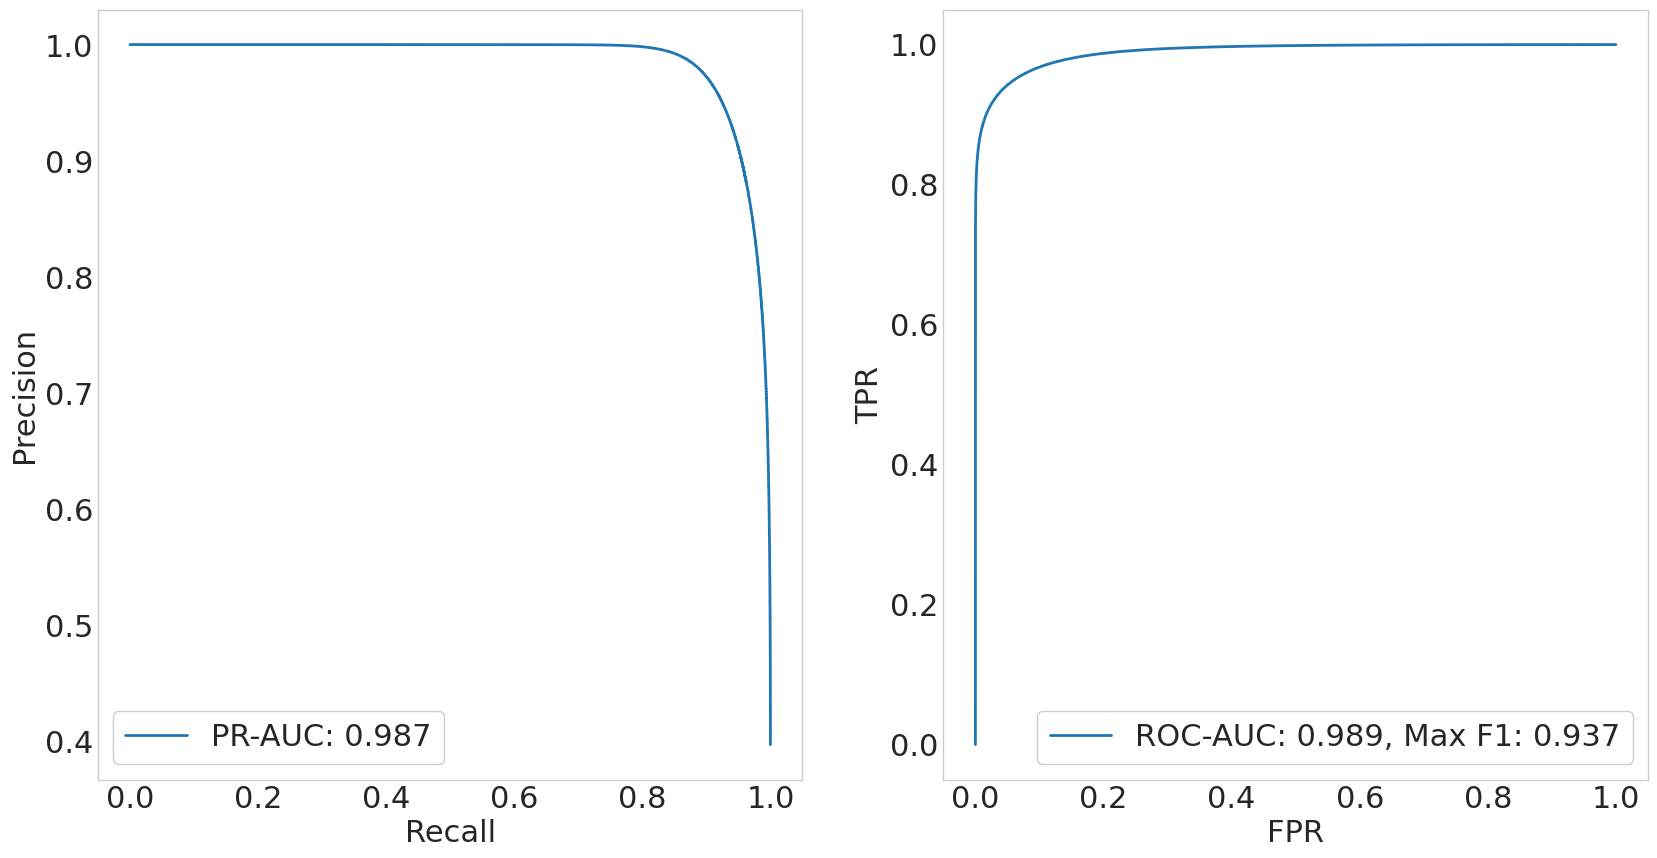

In [93]:
plot_roc_pr(pseu_df)

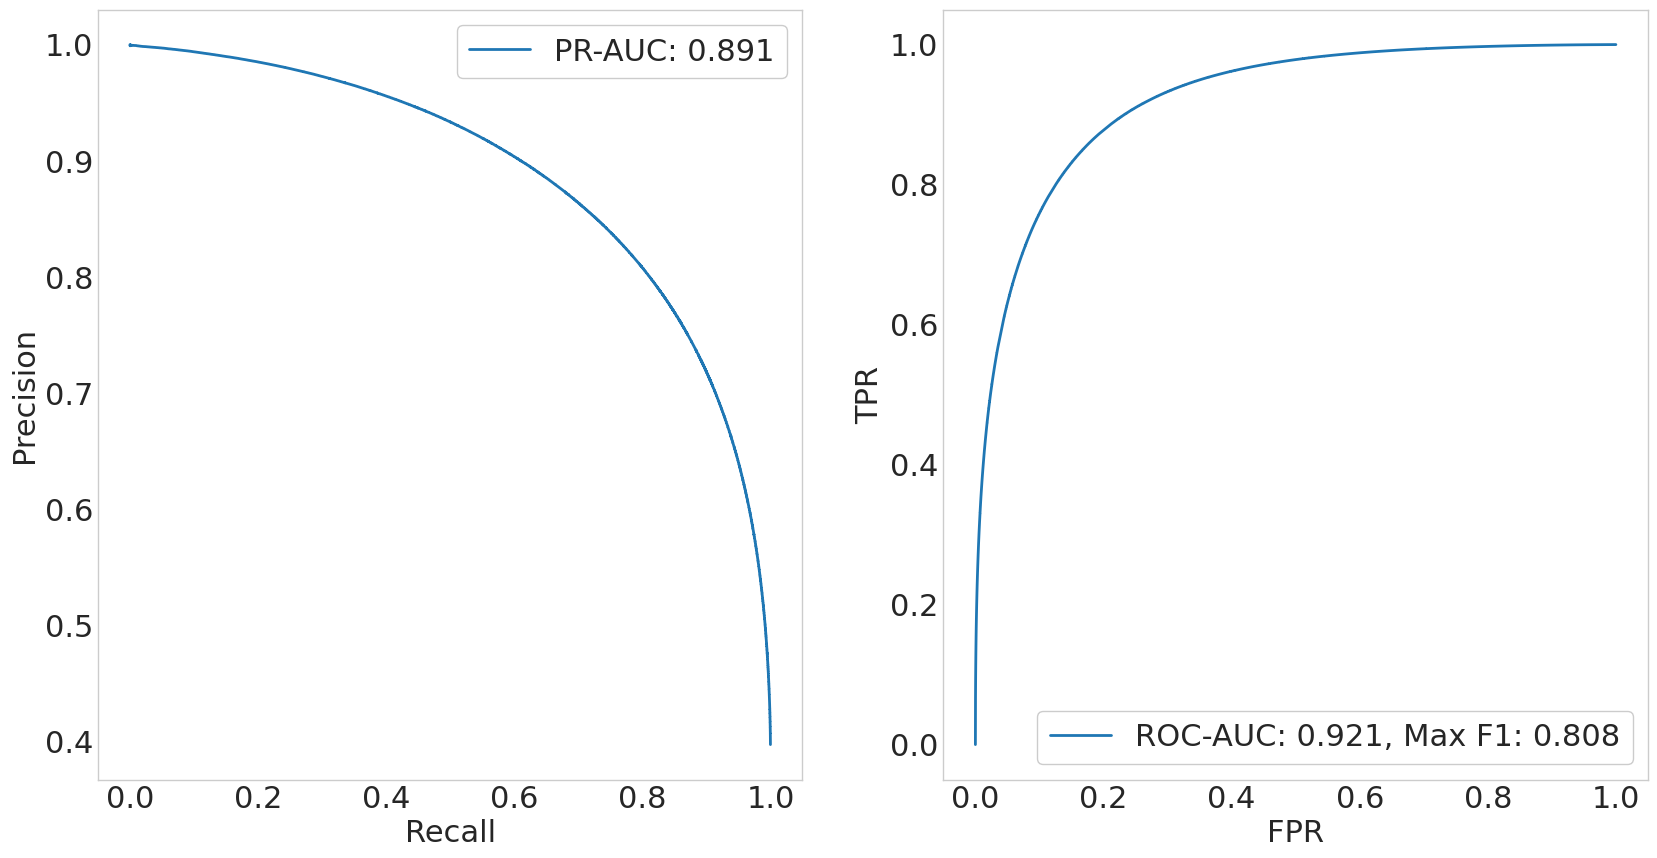

In [94]:
plot_roc_pr(m5c_df)

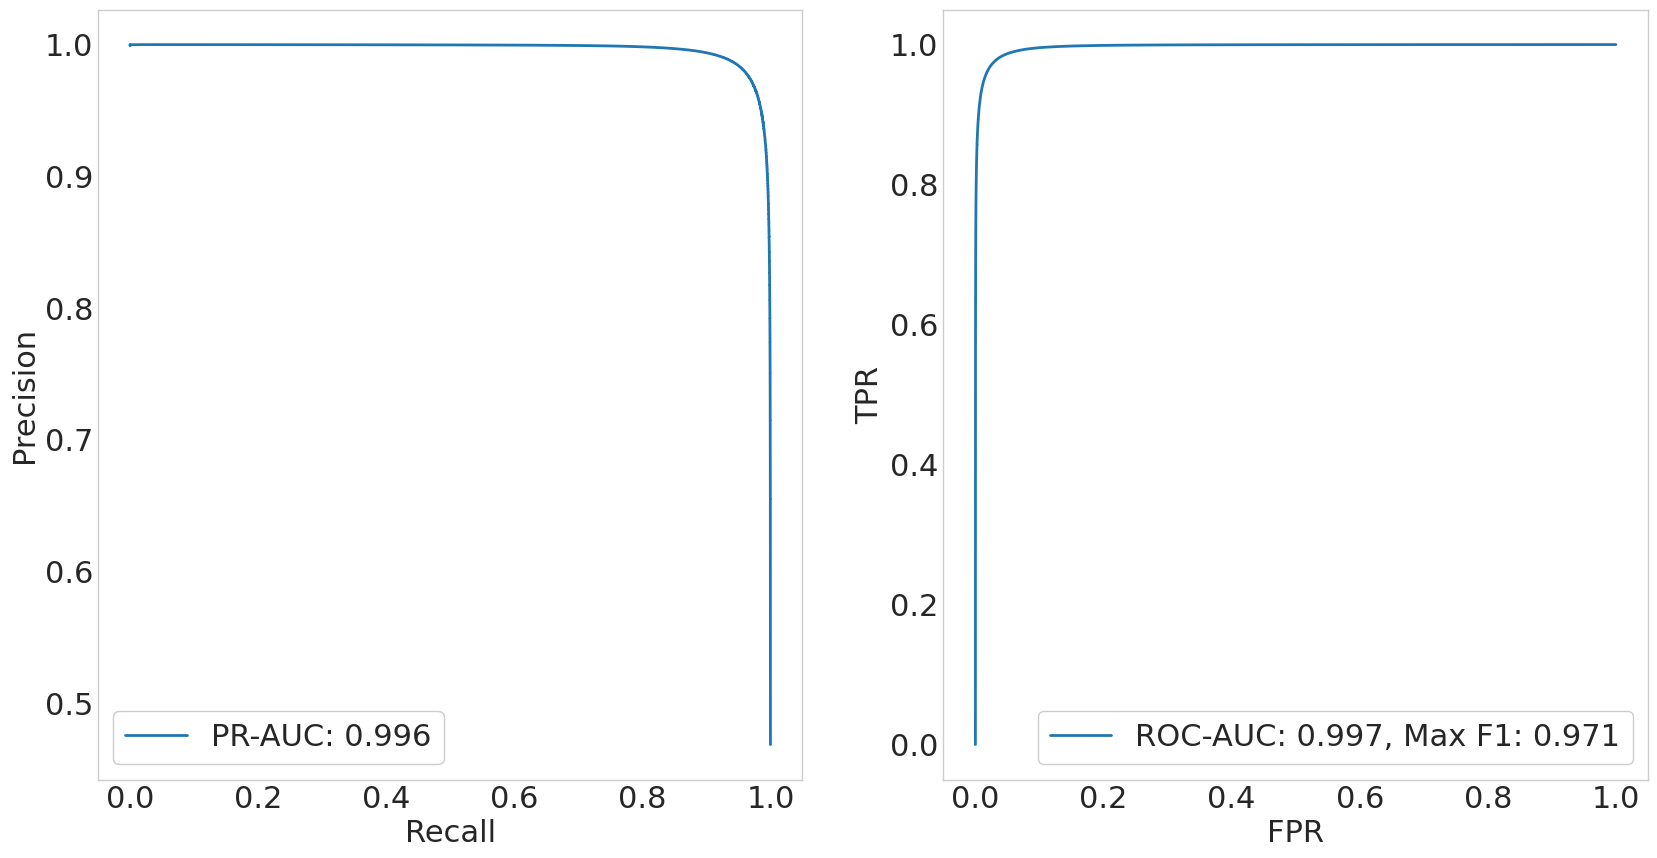

In [119]:
plot_roc_pr(gm_df)

In [113]:

def plot_roc_pr(df):
    precision, recall, thresholds = precision_recall_curve(df["target"], df["output"])
    pr_auc = auc(recall, precision)
    f1 = 2 * (precision * recall) / (precision + recall)
    max_f1 = np.max(f1)
    max_f1_recall = recall[np.argmax(f1)]
    max_f1_precision = precision[np.argmax(f1)]
    max_f1_threshold = thresholds[np.argmax(f1)]
    print(f"PR-AUC: {pr_auc:.3f}, Recall: {max_f1_recall:.3f}, Precision: {max_f1_precision:.3f}")
    
    shuffled_output = df["output"].sample(frac=1).values
    precision, recall, thresholds = precision_recall_curve(df["target"], shuffled_output)
    shuffled_pr_auc = auc(recall, precision)
    shuffled_max_f1_recall = recall[np.argmax(f1)]
    shuffled_max_f1_precision = precision[np.argmax(f1)]
    shuffled_max_f1_threshold = thresholds[np.argmax(f1)]
    print(f"Shuffled PR-AUC: {shuffled_pr_auc:.3f}, Recall: {shuffled_max_f1_recall:.3f}, Precision: {shuffled_max_f1_precision:.3f}")
    return None



In [114]:
plot_roc_pr(pseu_df)

PR-AUC: 0.987, Recall: 0.921, Precision: 0.954
Shuffled PR-AUC: 0.415, Recall: 0.383, Precision: 0.397


In [115]:
plot_roc_pr(m5c_df)

PR-AUC: 0.891, Recall: 0.844, Precision: 0.775
Shuffled PR-AUC: 0.397, Recall: 0.432, Precision: 0.397
